## Notebook 2: Preprocessing
### Merge all cleaned data into one master dataframe
### Handle missing data and outliers

____________

In [24]:
# Reload the raw mood CSV to check what notebook 1 actually saved
df_mood_check = pd.read_csv(PROCESSED_DIR / "mood.csv")
df_mood_check["date"] = pd.to_datetime(df_mood_check["date"], utc=True).dt.tz_localize(None).dt.normalize()

print(f"Raw mood file rows: {len(df_mood_check)}")
print(f"Unique participants in mood file: {df_mood_check['hashed_uid'].nunique()}")
print(f"Date range in mood file: {df_mood_check['date'].min().date()} to {df_mood_check['date'].max().date()}")
print(f"\nResponses per participant:")
print(df_mood_check.groupby('hashed_uid')['mood_score'].count().describe())

Raw mood file rows: 124
Unique participants in mood file: 29
Date range in mood file: 2013-04-24 to 2013-05-31

Responses per participant:
count    29.000000
mean      4.275862
std       4.934547
min       1.000000
25%       1.000000
50%       2.000000
75%       4.000000
max      21.000000
Name: mood_score, dtype: float64


### *Main Student Life Data*

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")

# Load all cleaned CSVs from notebook 1
df_activity     = pd.read_csv(PROCESSED_DIR / "activity.csv")
df_phonelock    = pd.read_csv(PROCESSED_DIR / "phonelock.csv")
df_conversation = pd.read_csv(PROCESSED_DIR / "conversation.csv")
df_mood         = pd.read_csv(PROCESSED_DIR / "mood.csv")
df_stress       = pd.read_csv(PROCESSED_DIR / "stress.csv")
df_sleep        = pd.read_csv(PROCESSED_DIR / "sleep.csv")
df_phq9         = pd.read_csv(PROCESSED_DIR / "phq9.csv")

print("All files loaded.")

All files loaded.


### Step 1: Standardize date columns
The mood, stress, and sleep date columns are tz-aware timestamps from notebook 1.
We strip the timezone and normalise all date columns to plain dates so they
merge correctly with activity, phonelock, and conversation.

In [ ]:
def clean_date_col(df):
    """Convert date column to plain tz-naive date for consistent merging."""
    df["date"] = pd.to_datetime(df["date"], utc=True).dt.tz_localize(None).dt.normalize()
    return df

# activity, phonelock, conversation have plain dates: just normalize
for df in [df_activity, df_phonelock, df_conversation]:
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()

# mood, stress, sleep have tz-aware timestamps: strip timezone first
for df in [df_mood, df_stress, df_sleep]:
    df = clean_date_col(df)

# Re-assign explicitly since the loop doesn't modify in place
df_mood  = clean_date_col(df_mood)
df_stress = clean_date_col(df_stress)
df_sleep  = clean_date_col(df_sleep)

print("Date columns standardised.")
print(f"Example mood date: {df_mood['date'].iloc[0]}")
print(f"Example activity date: {df_activity['date'].iloc[0]}")

Date columns standardised.
Example mood date: 2013-04-29 00:00:00
Example activity date: 2013-03-27 00:00:00


### Step 2: Merge into one master dataframe
We merge on hashed_uid + date using outer joins so we keep all participant-days
even if some sensors have missing data on a given day.
Mood is our outcome variable — we drop rows where mood is missing entirely
since those days cannot contribute to the analysis.

In [3]:
# Start with mood as the base — it is our outcome variable
df = df_mood.copy()

# Merge in each sensor and EMA dataframe on participant + date
df = df.merge(df_activity,     on=["hashed_uid", "date"], how="outer")
df = df.merge(df_phonelock,    on=["hashed_uid", "date"], how="outer")
df = df.merge(df_conversation, on=["hashed_uid", "date"], how="outer")
df = df.merge(df_stress,       on=["hashed_uid", "date"], how="outer")
df = df.merge(df_sleep,        on=["hashed_uid", "date"], how="outer")

# Merge PHQ-9 on hashed_uid only (no date — it is a one-time baseline survey)
# Keep only the pre-study score as our baseline mental health measure
df_phq9_pre = df_phq9[df_phq9["type"] == "pre"][["hashed_uid", "phq9_score"]].copy()
df_phq9_pre = df_phq9_pre.rename(columns={"phq9_score": "phq9_pre"})
df = df.merge(df_phq9_pre, on="hashed_uid", how="left")

# Drop rows where mood score is missing — these cannot be used in analysis
df = df.dropna(subset=["mood_score"])

# Sort by participant and date
df = df.sort_values(["hashed_uid", "date"]).reset_index(drop=True)

print(f"Master dataframe: {len(df)} participant-days, {df['hashed_uid'].nunique()} participants")
print(df.head())

Master dataframe: 124 participant-days, 29 participants
         hashed_uid       date  mood_score  happy_raw  sad_raw  \
0  02b34100f41b4332 2013-04-29         3.0        1.0      2.0   
1  02b34100f41b4332 2013-05-05         3.0        2.0      3.0   
2  02b34100f41b4332 2013-05-15         1.0        1.0      4.0   
3  02b34100f41b4332 2013-05-16         1.0        1.0      4.0   
4  02b34100f41b4332 2013-05-17         2.0        1.0      3.0   

   frac_stationary  n_activity_readings  phonelock_hours  conversation_hours  \
0         0.953881               8283.0        19.176389            3.555556   
1         0.972340               8279.0        22.721944            2.260556   
2         0.963952               8239.0        22.178056            3.384167   
3         1.000000               8340.0         9.333056            1.736944   
4         0.947859               8266.0        21.014167            5.718056   

   stress_level  sleep_hours  sleep_quality  phq9_pre  
0         

### Step 3: Explore missing data
Before deciding how to handle missing values, let's see exactly
what is missing, how much, and for which participants.

In [8]:
# Overall missing rate per column
print("=== Missing rates per column ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print(missing_df)

=== Missing rates per column ===
                     missing_count  missing_pct
sleep_hours                     58        46.77
sleep_quality                   58        46.77
stress_level                    42        33.87
phonelock_hours                  6         4.84
n_activity_readings              4         3.23
conversation_hours               3         2.42
frac_stationary                  2         1.61


In [9]:
# How many days does each participant have missing mood, sensor data etc.
print("=== Missing mood scores per participant ===")
mood_missing = df.groupby("hashed_uid")["mood_score"].apply(lambda x: x.isnull().sum())
print(mood_missing[mood_missing > 0])

print("\n=== Missing frac_stationary per participant ===")
act_missing = df.groupby("hashed_uid")["frac_stationary"].apply(lambda x: x.isnull().sum())
print(act_missing[act_missing > 0])

print("\n=== Missing phonelock_hours per participant ===")
lock_missing = df.groupby("hashed_uid")["phonelock_hours"].apply(lambda x: x.isnull().sum())
print(lock_missing[lock_missing > 0])

print("\n=== Missing conversation_hours per participant ===")
conv_missing = df.groupby("hashed_uid")["conversation_hours"].apply(lambda x: x.isnull().sum())
print(conv_missing[conv_missing > 0])

=== Missing mood scores per participant ===
Series([], Name: mood_score, dtype: int64)

=== Missing frac_stationary per participant ===
hashed_uid
24a62f53b639939c    2
Name: frac_stationary, dtype: int64

=== Missing phonelock_hours per participant ===
hashed_uid
24a62f53b639939c    2
7d68780d2921e43a    1
84b0b4eb371de2e2    2
b8f706e7df594c66    1
Name: phonelock_hours, dtype: int64

=== Missing conversation_hours per participant ===
hashed_uid
24a62f53b639939c    2
cda188c15b09fbc7    1
Name: conversation_hours, dtype: int64


In [12]:
# Look at the raw dataframe to see how missing values are marked
print("=== First 20 rows of master dataframe ===")
print(df.head(20).to_string())

print("\n=== Data types per column ===")
print(df.dtypes)

print("\n=== Sample of rows where frac_stationary is missing ===")
print(df[df["frac_stationary"].isna()].head(10).to_string())

print("\n=== Sample of rows where phonelock_hours is missing ===")
print(df[df["phonelock_hours"].isna()].head(10).to_string())

print("\n=== Sample of rows where conversation_hours is missing ===")
print(df[df["conversation_hours"].isna()].head(10).to_string())

print("\n=== Sample of rows where sleep_hours is missing ===")
print(df[df["sleep_hours"].isna()].head(10).to_string())

=== First 20 rows of master dataframe ===
          hashed_uid       date  mood_score  happy_raw  sad_raw  frac_stationary  n_activity_readings  phonelock_hours  conversation_hours  stress_level  sleep_hours  sleep_quality  phq9_pre  is_weekend  week_num  is_midterm_period  is_preexam_break  is_finals_period  is_memorial_day  is_boston_bombing  temp_c  precip_mm  is_rainy
0   02b34100f41b4332 2013-04-29         3.0        1.0      2.0         0.953881               8283.0        19.176389            3.555556           3.0          4.0            2.0      13.0           0         6                  1                 0                 0                0                  0    11.8        0.0         0
1   02b34100f41b4332 2013-05-05         3.0        2.0      3.0         0.972340               8279.0        22.721944            2.260556           NaN          NaN            NaN      13.0           1         6                  0                 0                 0                0        

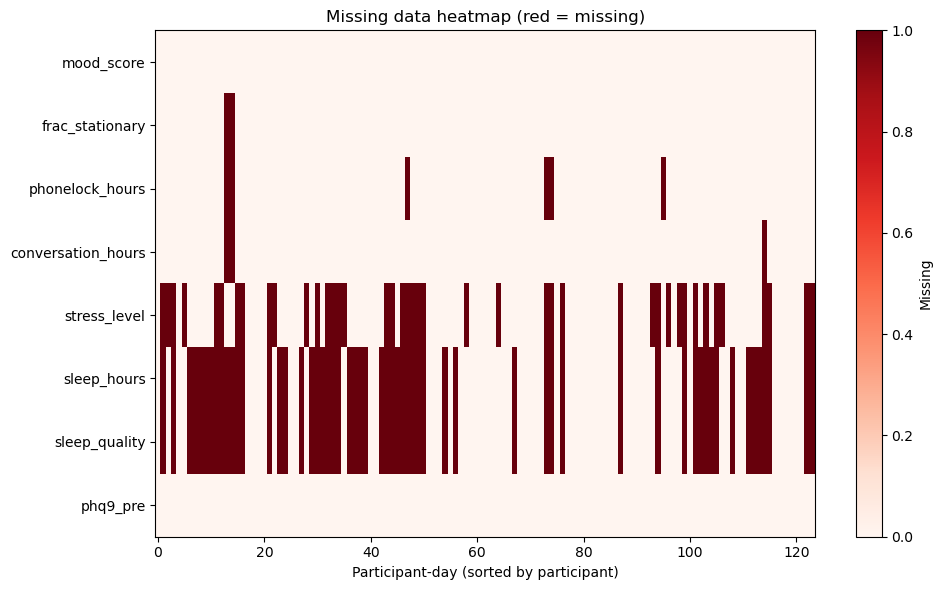

Heatmap saved to output/missing_data_heatmap.png


In [11]:
import matplotlib.pyplot as plt

# Heatmap of missingness across participants and columns
check_cols = ["mood_score", "frac_stationary", "phonelock_hours",
              "conversation_hours", "stress_level", "sleep_hours",
              "sleep_quality", "phq9_pre"]

missing_matrix = df.set_index("hashed_uid")[check_cols].isnull().astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(missing_matrix.T, aspect="auto", cmap="Reds", interpolation="none")
ax.set_yticks(range(len(check_cols)))
ax.set_yticklabels(check_cols)
ax.set_xlabel("Participant-day (sorted by participant)")
ax.set_title("Missing data heatmap (red = missing)")
plt.colorbar(im, ax=ax, label="Missing")
plt.tight_layout()
plt.savefig("../output/missing_data_heatmap.png", dpi=150)
plt.show()
print("Heatmap saved to output/missing_data_heatmap.png")

### Step 4: Explore outliers
Before removing anything, let's look at the distributions of each
continuous sensor column to see what the outliers actually are.

In [13]:
# Summary statistics for continuous sensor columns
sensor_cols = ["frac_stationary", "phonelock_hours", "conversation_hours",
               "sleep_hours", "mood_score", "stress_level"]

print("=== Distribution summary ===")
print(df[sensor_cols].describe().round(3))

=== Distribution summary ===
       frac_stationary  phonelock_hours  conversation_hours  sleep_hours  \
count          122.000          118.000             121.000       66.000   
mean             0.930           11.609               4.207        8.288   
std              0.063            5.905               2.786        2.528   
min              0.602            1.091               0.025        1.000   
25%              0.911            8.151               2.013        7.000   
50%              0.946           11.242               3.717        8.000   
75%              0.968           14.632               5.768        9.000   
max              1.000           26.564              12.005       14.000   

       mood_score  stress_level  
count     124.000        82.000  
mean        4.056         2.415  
std         1.399         1.206  
min         1.000         1.000  
25%         4.000         1.000  
50%         4.000         2.000  
75%         5.000         3.000  
max         7.

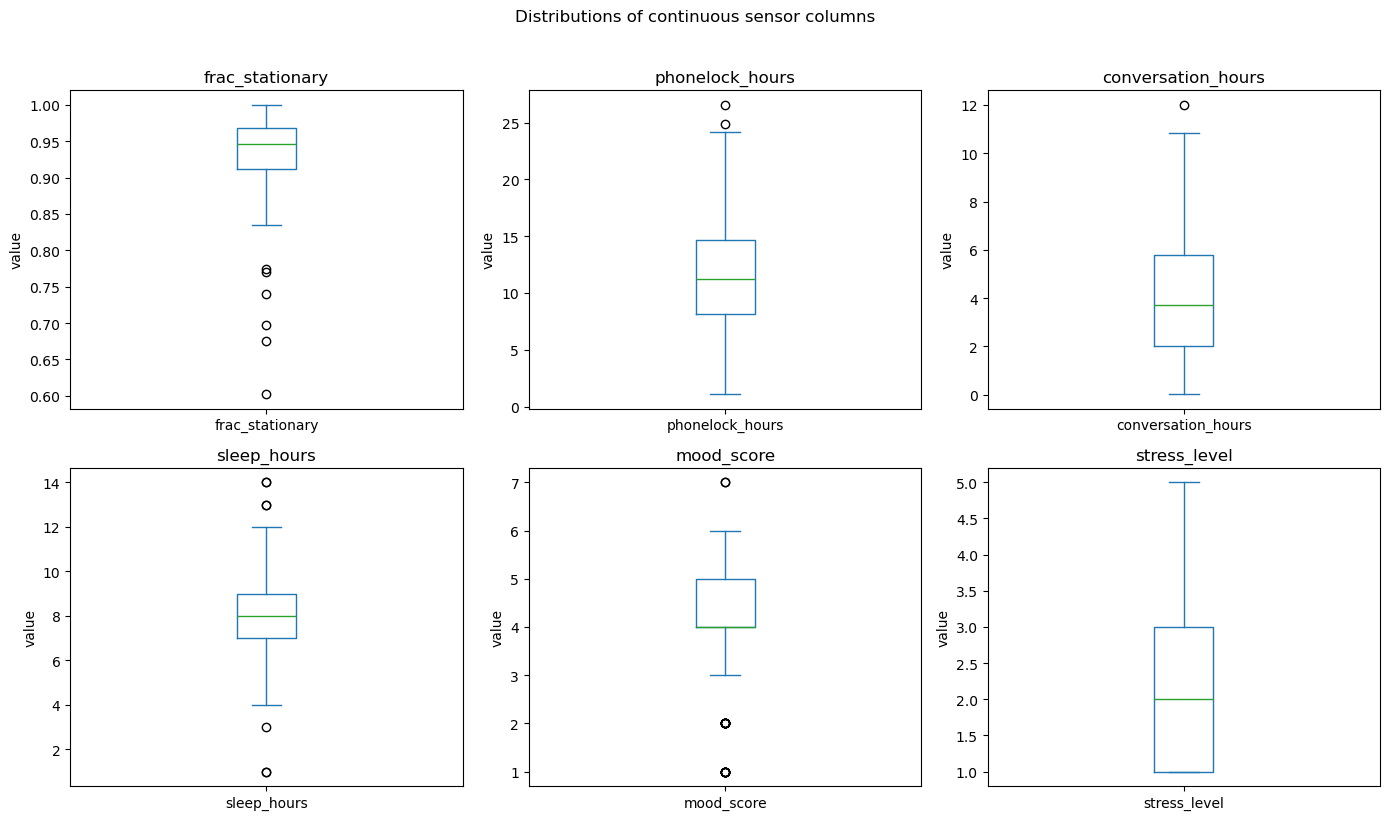

Boxplots saved to output/boxplots.png


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    if col in df.columns:
        df[col].dropna().plot(kind="box", ax=axes[i], title=col)
        axes[i].set_ylabel("value")

plt.suptitle("Distributions of continuous sensor columns", y=1.02)
plt.tight_layout()
plt.savefig("../output/boxplots.png", dpi=150)
plt.show()
print("Boxplots saved to output/boxplots.png")

In [15]:
# Show the actual rows that would be flagged as outliers under IQR x 3
def show_outliers(df, col, multiplier=3):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][["hashed_uid", "date", col]]
    print(f"\n{col}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
    print(f"  Bounds: {lower:.2f} to {upper:.2f}")
    print(f"  Outliers found: {len(outliers)}")
    if len(outliers) > 0:
        print(outliers.to_string())

for col in ["frac_stationary", "phonelock_hours", "conversation_hours", "sleep_hours"]:
    if col in df.columns:
        show_outliers(df, col)


frac_stationary: Q1=0.91, Q3=0.97, IQR=0.06
  Bounds: 0.74 to 1.14
  Outliers found: 4
           hashed_uid       date  frac_stationary
9    02b34100f41b4332 2013-05-31         0.696930
48   7d68780d2921e43a 2013-05-16         0.740013
109  cd6251b4de52453b 2013-05-16         0.675445
113  cd6251b4de52453b 2013-05-22         0.602151

phonelock_hours: Q1=8.15, Q3=14.63, IQR=6.48
  Bounds: -11.29 to 34.08
  Outliers found: 0

conversation_hours: Q1=2.01, Q3=5.77, IQR=3.76
  Bounds: -9.25 to 17.03
  Outliers found: 0

sleep_hours: Q1=7.00, Q3=9.00, IQR=2.00
  Bounds: 1.00 to 15.00
  Outliers found: 0


    What the outlier inspection tells us

**frac_stationary: 4 flagged values (0.60–0.74)**
These are days with unusually high movement. Dates cluster around May 16, 22, and 31
(mid-finals period). Low stationary fraction during finals is a plausible real behavioral
signal — students moving around more under stress. These are not sensor errors.
Decision: keep all values, no removal.

**phonelock_hours, conversation_hours, sleep_hours: 0 outliers**
All values fall within plausible real-world ranges. No action needed.

**mood_score, stress_level: fixed ordinal scales**
Min and max values are scale endpoints (1–7 and 1–5), not errors. No action needed.

**Outlier decision: no values removed.**
The dataset is small (n=48, ~124 participant-days with mood) — removing valid
behavioral observations would reduce already limited statistical power.

### Step 5: Handle missing data
Mood is already guaranteed non-null (dropped in merge step).
For sensor columns, we forward-fill small gaps of up to 2 consecutive
missing days within each participant, then report remaining missing rates.
We do not impute beyond 2 days — larger gaps are left as NaN.

In [ ]:
# Forward-fill only passive sensor streams where gaps represent missing recordings
# NOT self-reported EMA fields like sleep_hours which vary day to day
sensor_cols = ["frac_stationary", "phonelock_hours", "conversation_hours"]

# Forward-fill within each participant, max 2 consecutive days
df = df.sort_values(["hashed_uid", "date"])
df[sensor_cols] = (
    df.groupby("hashed_uid")[sensor_cols]
    .transform(lambda x: x.ffill(limit=2))
)

# Report missing rates after forward-fill
print("Missing rates after forward-fill:")
all_cols = sensor_cols + ["stress_level", "sleep_hours", "sleep_quality", "phq9_pre"]
for col in all_cols:
    if col in df.columns:
        rate = df[col].isna().mean()
        print(f"  {col}: {rate:.1%}")

Missing rates after forward-fill:
  frac_stationary: 1.6%
  phonelock_hours: 4.8%
  conversation_hours: 2.4%
  stress_level: 33.9%
  sleep_hours: 46.8%
  sleep_quality: 46.8%
  phq9_pre: 0.0%


    What the missing rates tell us

**Passive sensors (frac_stationary, phonelock_hours, conversation_hours): < 5%**
Small gaps from app/phone downtime, not participant behavior. Forward-fill up to 2 days is appropriate.

**Active EMA (stress_level: 33.9%, sleep_hours/quality: 46.8%)**
High missingness reflects low compliance — students skipped the prompt. Imputing would be inappropriate. Left as NaN.

**PHQ-9 (0.0%)** — no action needed.


### Step 6: Outlier removal
We use IQR x 3 on continuous sensor columns to remove extreme values
that are likely sensor errors rather than real behavioral signals.
Values outside this range are set to NaN rather than dropped entirely,
so we don't lose the whole participant-day.

In [17]:
# No outlier removal applied.
# See markdown above for reasoning — flagged values are plausible behavioral signals,
# not sensor errors. Removing them would reduce statistical power in an already small dataset.
print("No outliers removed. See markdown cell above for decision rationale.")

No outliers removed. See markdown cell above for decision rationale.


### Step 7: Save student life cleaned data

In [23]:
# Save the cleaned student life master dataframe
df.to_csv(PROCESSED_DIR / "student_life_master.csv", index=False)
print(f"Cleaned master dataframe saved to {PROCESSED_DIR / 'student_life_cleaned.csv'}")

Cleaned master dataframe saved to ../data/processed/student_life_cleaned.csv
